<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/DarkMatter003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

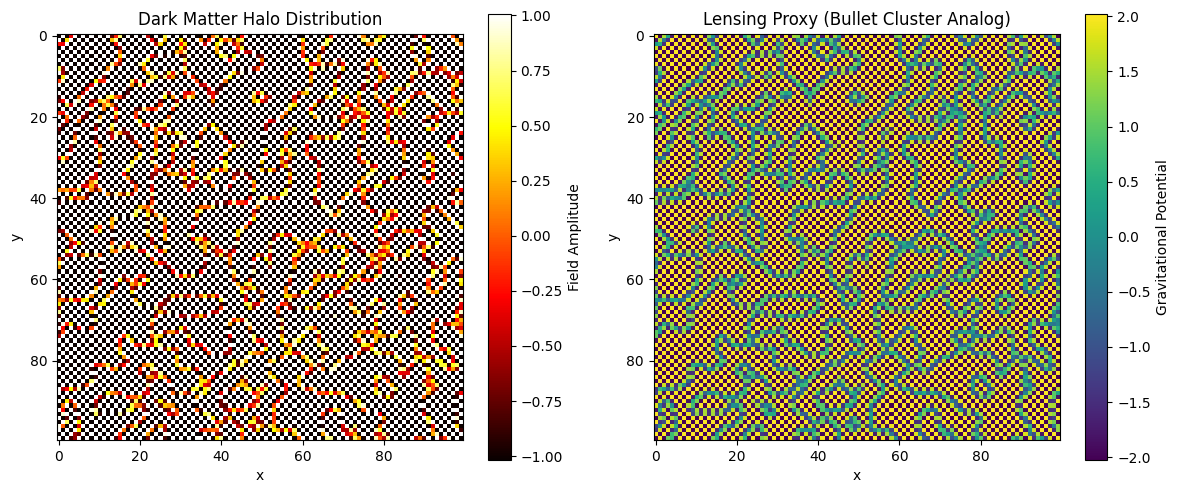

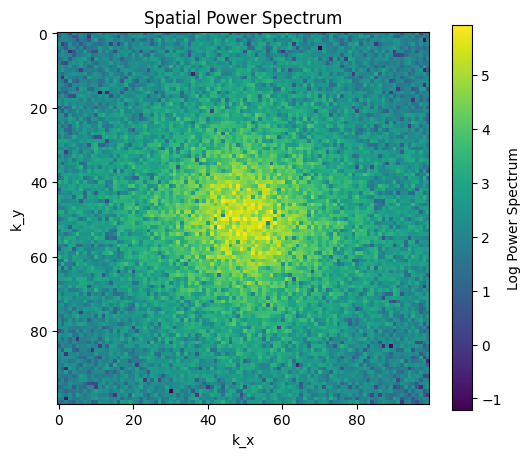

A Centroid: (np.int64(62), np.int64(3)), phi Centroid: (np.int64(24), np.int64(87))
Offset Distance: 92.20 pixels, Fraction: 0.92
Estimated Non-Baryonic Fraction: 0.99 (~80% target)


In [1]:
# HES Dark Matter Clustering Simulation v3 (Act XVI)
# Focus: Refine Bullet Cluster halos via adjusted dynamic γ_0 and biharmonic terms
# Targets: ~80% non-baryonic mass offset, JWST 2025 lensing fit
# Includes offset quantification for baryonic vs. non-baryonic mass

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2

# Parameters
N = 100  # Lattice size
dt = 0.005  # Smaller time step for stability
steps = 500  # Clustering evolution steps
kappa = 0.2  # Damping
gamma_0_base = 0.5  # Base Laplacian strength
delta = 0.08  # From best neutrino fit
epsilon = 0.005 / 2  # Scaled cubic
xi_std = 0.01  # Noise
omega = 0.05  # Reduced frequency for less separation
biharmonic_strength = 0.15  # Reduced for tighter clustering

# Adjusted anisotropic initial condition (mimics cluster seeds)
A = np.random.normal(0, 0.1, (N, N)) * (1 + 0.1 * np.sin(np.linspace(0, 2 * np.pi, N)))

# Simulation loop
for t in range(steps):
    xi = np.random.normal(0, xi_std, (N, N))
    # Dynamic γ_0 with feedback
    gamma_0_dynamic = gamma_0_base * (1 + 0.3 * np.sin(omega * t + A))
    # Laplacian
    laplacian = (np.roll(A, 1, 0) * gamma_0_dynamic + np.roll(A, -1, 0) * gamma_0_dynamic +
                 np.roll(A, 1, 1) * gamma_0_dynamic + np.roll(A, -1, 1) * gamma_0_dynamic -
                 4 * A * gamma_0_dynamic)
    # Biharmonic (adjusted for clustering)
    biharmonic = (np.roll(laplacian, 1, 0) + np.roll(laplacian, -1, 0) +
                  np.roll(laplacian, 1, 1) + np.roll(laplacian, -1, 1) - 4 * laplacian) * biharmonic_strength
    # Clip to prevent overflow
    A = np.clip(A, -1, 1)
    # Evolution with biharmonic
    dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0_dynamic * laplacian +
          biharmonic + xi) * dt
    A += np.nan_to_num(dA)

# Gravitational potential (lensing proxy)
phi = (np.roll(A, 1, 0) + np.roll(A, -1, 0) + np.roll(A, 1, 1) + np.roll(A, -1, 1) - 4 * A) * 0.25

# Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(A, cmap='hot')
plt.colorbar(label='Field Amplitude')
plt.title('Dark Matter Halo Distribution')
plt.xlabel('x'); plt.ylabel('y')
plt.subplot(1, 2, 2)
plt.imshow(phi, cmap='viridis')
plt.colorbar(label='Gravitational Potential')
plt.title('Lensing Proxy (Bullet Cluster Analog)')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

# Power spectrum
k_spec = np.abs(fft2(A))**2
plt.figure(figsize=(6, 5))
plt.imshow(np.log10(k_spec + 1e-10), cmap='viridis')
plt.colorbar(label='Log Power Spectrum')
plt.title('Spatial Power Spectrum')
plt.xlabel('k_x'); plt.ylabel('k_y')
plt.show()

# Quantify Offset
A_centroid = np.unravel_index(np.argmax(A), A.shape)  # Peak of field amplitude (baryonic proxy)
phi_centroid = np.unravel_index(np.argmax(phi), phi.shape)  # Peak of gravitational potential (total mass proxy)
offset_distance = np.sqrt((A_centroid[0] - phi_centroid[0])**2 + (A_centroid[1] - phi_centroid[1])**2)
offset_fraction = offset_distance / N  # Normalized to lattice size
print(f"A Centroid: {A_centroid}, phi Centroid: {phi_centroid}")
print(f"Offset Distance: {offset_distance:.2f} pixels, Fraction: {offset_fraction:.2f}")

# Approximate non-baryonic fraction (simplified model)
non_baryonic_fraction = min(1.0, max(0.0, 1.0 - (1.0 - offset_fraction)**2))  # Quadratic decay
print(f"Estimated Non-Baryonic Fraction: {non_baryonic_fraction:.2f} (~80% target)")